In [ ]:
# Mount your google drive in google colab
from google.colab import drive
drive.mount('/content/drive')

#depend. problem with rich 13.3

!pip install torch==1.13.1
!pip install torchaudio==0.13.1
!pip install torchmetrics==0.11.4
!pip install torchsummary==1.5.1
!pip install torchtext==0.14.1
!pip install torchvision==0.14.1
!pip install rich==13.2
import rich
!pip install matplotlib==3.5.3
!pip install --quiet scvi-colab==0.11.0


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.5/887.5 MB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 67.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 75.6 MB/s eta 0:00:00
  Attempting uninstall: torch
    Found existing installation: torch 2.1.0+cu121
    Uninstalling torch-2.1.0+cu121:
      Successfully uninstalled torch-2.1.0+cu121
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.1.0+cu121 requires torch==2.1.0, but you have torch 1.13.1 which is incompatible.
torchdata 0.7.0 requires torch==2.1.0, but you have torch 1.13.1 which is incompatible.
torchtext 0.16.0 requires torch==2.1.0, 

In [ ]:
from scvi_colab import install
install()

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/usr/local/lib/python3.10/dist-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scvi
import scanpy as sc
import pandas as pd
import scipy
from scipy.stats import pearsonr

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/SusztakLabFiles/CosMx/adata/fetal/fetal_annotated_AllCells_model2_preSCANVI.h5ad")

In [ ]:
adata

AnnData object with n_obs × n_vars = 445895 × 995
    obs: 'sample', 'phase', 'type', 'cellType', 'cellType3', 'tech', 'cellType_CosMx_1', 'leiden', 'fov', 'cell_ID', 'pct_counts_mt', 'pct_nuc', 'total_counts', 'nCount_RNA', 'n_genes_by_counts', 'CenterX_global_px', 'CenterY_global_px', 'Area', 'Count_percentile', 'Mean.DAPI', 'Max.DAPI', 'G2M_score', 'S_score', 'gAge', 'AllCounts', '_scvi_batch', '_scvi_labels', 'mean_distance', 'worst_pct'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cellType3_colors', 'cellType_CosMx_1_colors', 'cellType_colors', 'leiden', 'neighbors', 'sample_colors', 'tech_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_scVI', 'X_umap', '_scvi_extra_categorical_covs', '_scvi_extra_continuous_covs', 'spatial', 'spatial_fov'
    layers: 'All_counts', 'Cytoplasm', 'Membrane', 'Nuclear', 'counts', 'log1p'
    obsp: 'connectivities', 'distances'

In [ ]:
Cosmx_cells_mask = (adata.obs['tech'] == 'CosMx')
scRNA_cells_mask = (adata.obs['tech'] != 'CosMx')

CosMx_index = np.where(Cosmx_cells_mask)[0]
scRNA_index = np.where(scRNA_cells_mask)[0]

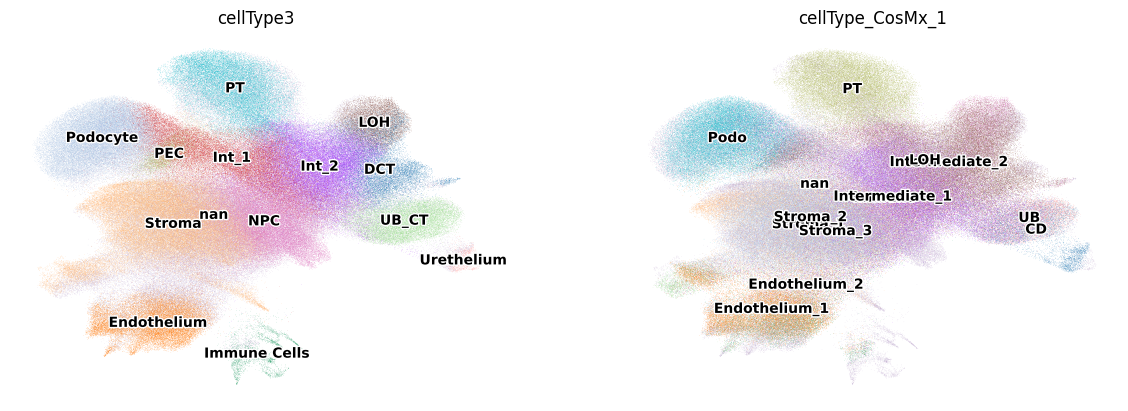

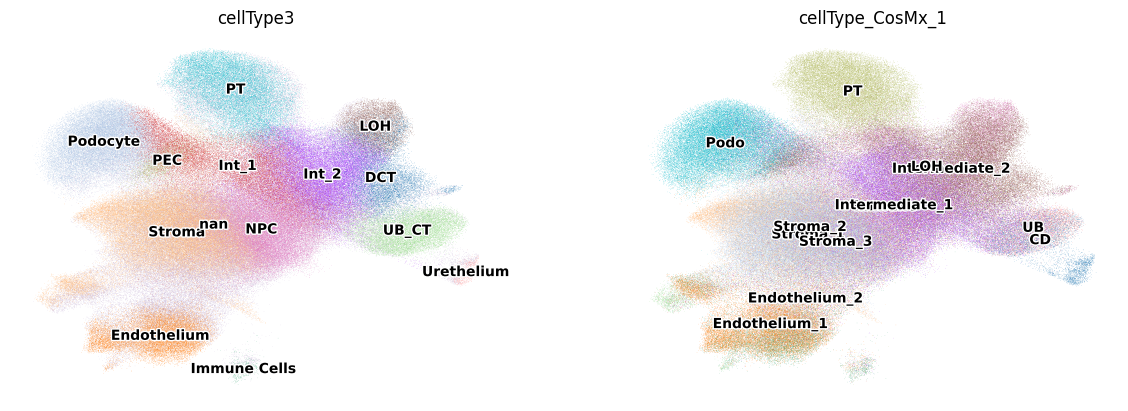

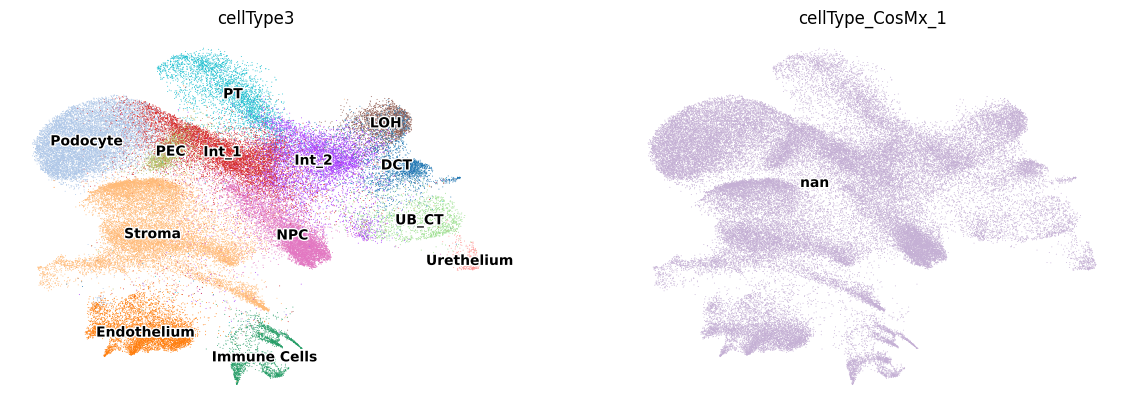

In [ ]:
sc.pl.umap(adata, color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
sc.pl.umap(adata[Cosmx_cells_mask,:], color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
sc.pl.umap(adata[scRNA_cells_mask,:], color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)


In [ ]:
adata.obs['pct_counts_mt'] = adata.obs['pct_counts_mt'].fillna(0)


In [ ]:
adata= adata.copy()

scvi.model.SCVI.setup_anndata(
    adata,
    batch_key="tech",
    layer="counts", categorical_covariate_keys=["sample", "phase"],
    continuous_covariate_keys=["Count_percentile","pct_counts_mt"])

model = scvi.model.SCVI(adata)
vae = scvi.model.SCVI(adata, n_layers=5, n_latent=30, gene_likelihood="nb", dropout_rate=0.1)
vae.train(max_epochs = 1000, plan_kwargs={"lr":0.001}, early_stopping = True)
model = vae

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 532/1000:  53%|█████▎    | 532/1000 [7:40:28<6:45:04, 51.93s/it, v_num=1, train_loss_step=284, train_loss_epoch=308]
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 306.616. Signaling Trainer to stop.


In [ ]:
model.save("/content/drive/MyDrive/SusztakLabFiles/CosMx/models/fetal_model_SCANVI2/")
vae = scvi.model.SCVI.load("/content/drive/MyDrive/SusztakLabFiles/CosMx/models/fetal_model_SCANVI2/", adata=adata, use_gpu=False)

INFO     File /content/drive/MyDrive/SusztakLabFiles/CosMx/models/fetal_model_SCANVI2/model.pt already downloaded  


/usr/local/lib/python3.10/dist-packages/scvi/model/base/_base_model.py:676: UserWarning: `use_gpu` is deprecated in v1.0 and will be removed in v1.1. Please use `accelerator` and `devices` instead.
  _, _, device = parse_device_args(


In [ ]:
adata.obs.tech.value_counts()

CosMx    380606
scRNA     65289
Name: tech, dtype: int64

In [ ]:
adata.obs["cellType3"].value_counts()

nan             95151
Stroma          79705
NPC             47884
Int_2           43986
Podocyte        42217
Int_1           34066
PT              26693
Endothelium     23774
UB_CT           16567
DCT             15531
LOH             10215
PEC              6171
Immune Cells     2825
Urethelium       1110
Name: cellType3, dtype: int64

In [ ]:
adata.obs["cellType3"].replace("NPC", "Int", inplace=True)
adata.obs["cellType3"].replace("Int_1", "Int", inplace=True)
adata.obs["cellType3"].replace("Int_2", "Int", inplace=True)

adata.obs["cellType3"].value_counts()

Int             125936
nan              95151
Stroma           79705
Podocyte         42217
PT               26693
Endothelium      23774
UB_CT            16567
DCT              15531
LOH              10215
PEC               6171
Immune Cells      2825
Urethelium        1110
Name: cellType3, dtype: int64

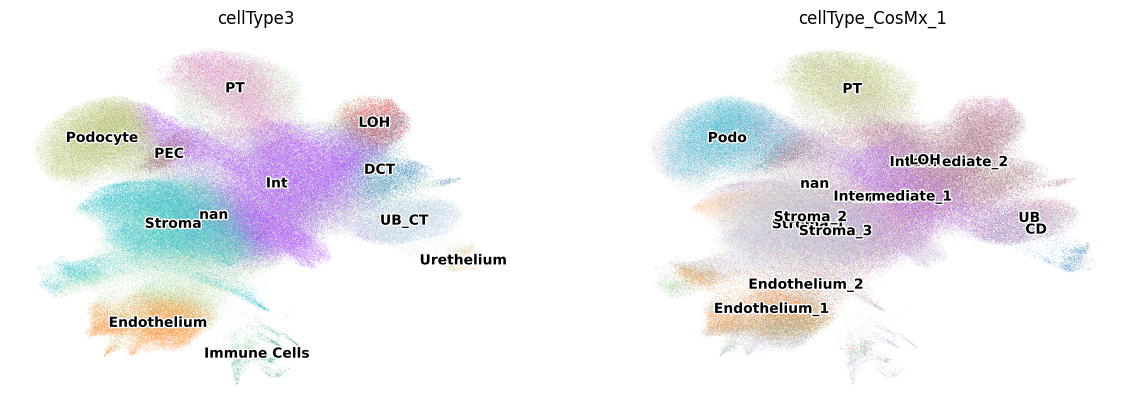

/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


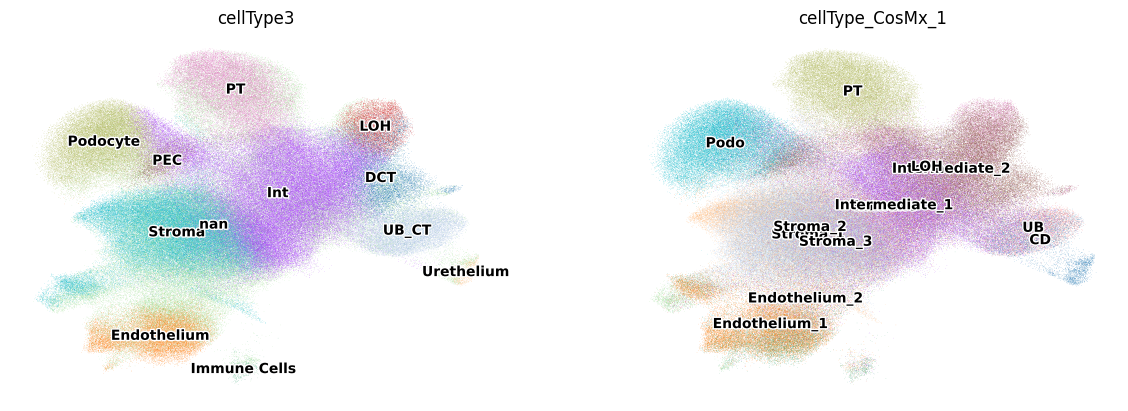

/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


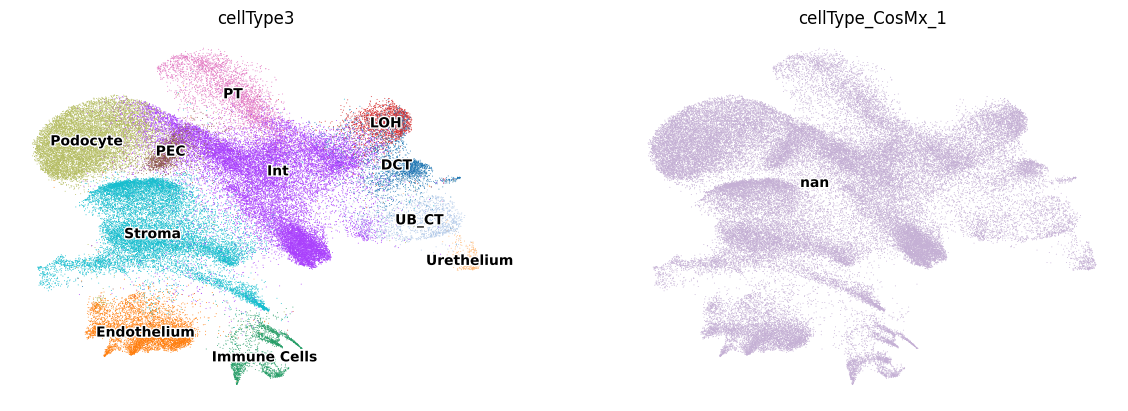

In [ ]:
sc.pl.umap(adata, color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
sc.pl.umap(adata[Cosmx_cells_mask,:], color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
sc.pl.umap(adata[scRNA_cells_mask,:], color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)


In [ ]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata,
    labels_key="cellType3",
    unlabeled_category="nan",
)

In [ ]:
scanvi_model.train(max_epochs=50)


INFO     Training for 50 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPUs
INFO:lightning.pytorch.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 50/50: 100%|██████████| 50/50 [1:52:14<00:00, 134.18s/it, v_num=1, train_loss_step=347, train_loss_epoch=376]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [1:52:14<00:00, 134.69s/it, v_num=1, train_loss_step=347, train_loss_epoch=376]


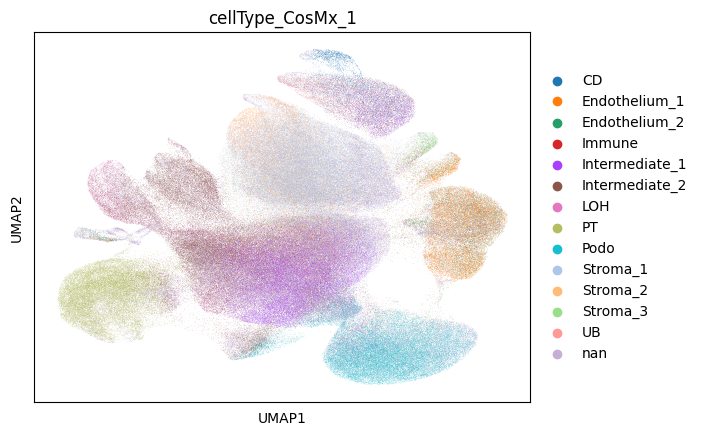

In [ ]:
SCANVI_LATENT_KEY = "X_scANVI"
adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata)

sc.pp.neighbors(adata, use_rep="X_scANVI")
sc.tl.leiden(adata)
sc.tl.umap(adata)

sc.pl.umap(adata, color = "cellType_CosMx_1")

In [ ]:
adata.write_h5ad(filename = "/content/drive/MyDrive/SusztakLabFiles/CosMx/adata/fetal/fetal_annotated_AllCells_model2_postSCANVI.h5ad")


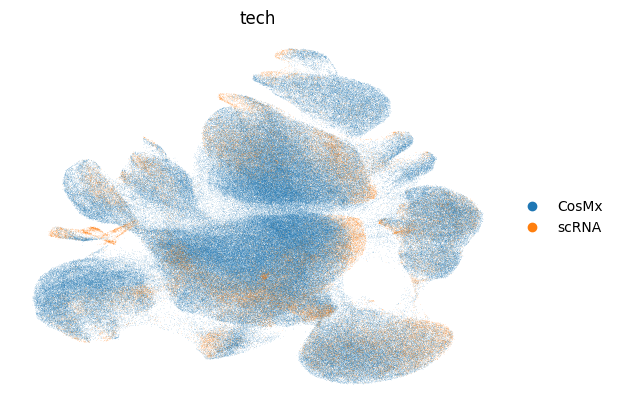

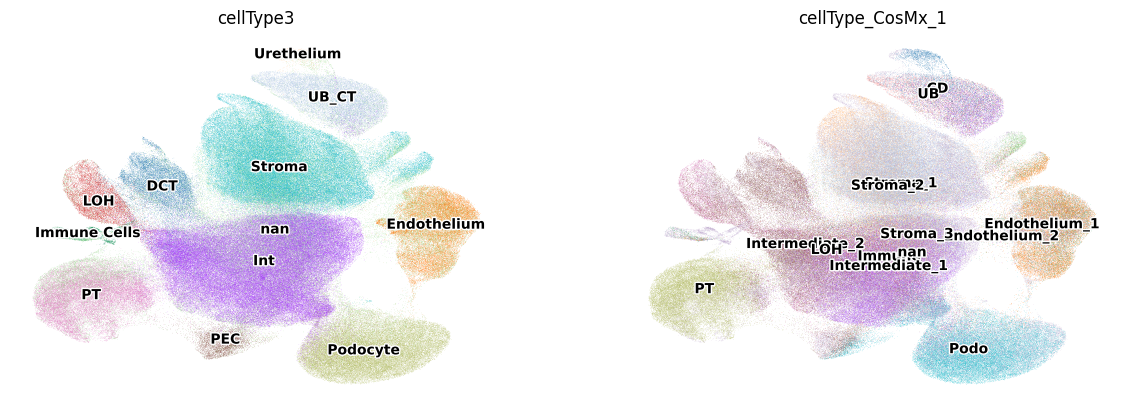

/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


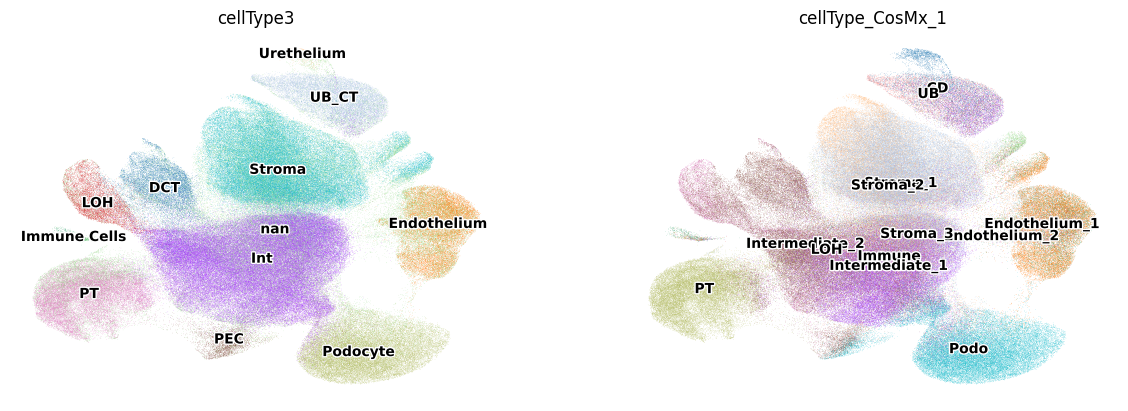

/usr/local/lib/python3.10/dist-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


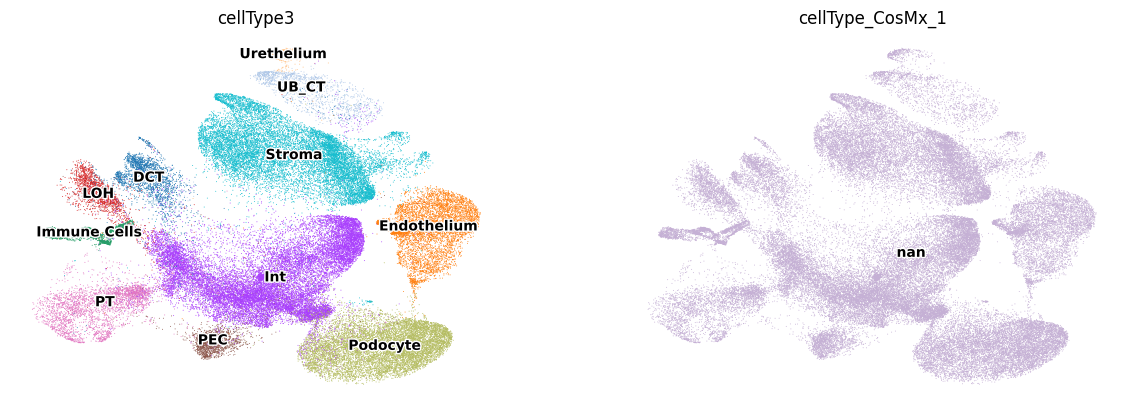

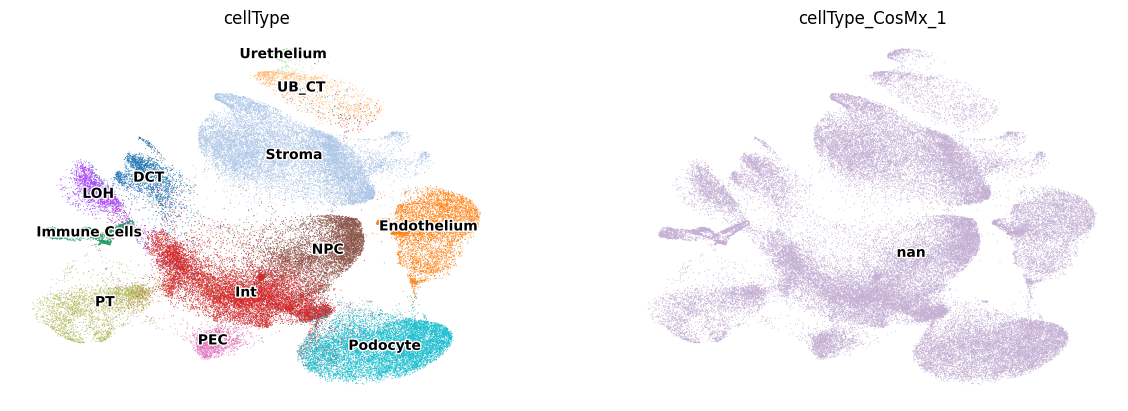

In [ ]:
sc.pl.umap(adata, color = ["tech"], frameon = False)

sc.pl.umap(adata, color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
sc.pl.umap(adata[Cosmx_cells_mask,:], color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
sc.pl.umap(adata[scRNA_cells_mask,:], color = ["cellType3","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
sc.pl.umap(adata[scRNA_cells_mask,:], color = ["cellType","cellType_CosMx_1"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)


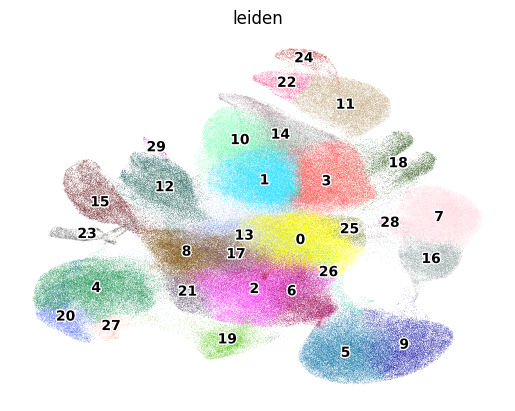

In [ ]:
sc.pl.umap(adata, color = ["leiden"], legend_loc='on data', legend_fontsize=10, legend_fontoutline=2, frameon = False)
